In [48]:
# Importación de librerías
import nltk
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    cross_val_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB

nltk.download(
    "punkt_tab"
)  # Descargamos el tokenizador de NLTK para poder usar word_tokenize
nltk.download(
    "stopwords"
)  # Descargamos las stopwords de NLTK para poder filtrar palabras comunes

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/pedropablosanintrujillo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pedropablosanintrujillo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [49]:
df = pd.read_csv("data/train.csv")

data = df.copy(deep=True)

print(f"Documentos cargados: {len(data)}")
data.head()

Documentos cargados: 12000


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


In [50]:
data.describe(include=["object"])

/var/folders/bl/m8gd2pc14237m1mz5n7dg_nw0000gn/T/ipykernel_38960/2389127942.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=["object"])


,text,label
count,12000,12000
unique,12000,3
top,Lo pedí un martes por la noche y me llegó al d...,positivo
freq,1,4212


In [51]:
data["label"].value_counts()

label
positivo    4212
negativo    4212
neutral     3576
Name: count, dtype: int64

In [52]:
import unicodedata


def quitar_tildes(text):
    """Elimina tildes y diéresis, pues muchas reseñas están escritas sin ellas."""
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")


spanish_stopwords_completas = set(stopwords.words("spanish"))

palabras_negativas = {
    "no",
    "nunca",
    "jamás",
    "nadie",
    "ninguno",
    "poco",
    "ni",
    "pero",
    "sin",
    "muy",
    "más",
    "mucho",
    "nada",
    "contra",
    "algo",
}



# Se comparan sin tildes porque el texto también se normaliza sin tildes
spanish_stopwords = {
    quitar_tildes(w) for w in spanish_stopwords_completas - palabras_negativas
}

# Lista mínima (artículos, preposiciones y pronombres) para no romper frases hechas como "con los ojos cerrados"
stopwords_minimas = {
    quitar_tildes(w)
    for w in [
        "el",
        "la",
        "los",
        "las",
        "un",
        "una",
        "unos",
        "unas",
        "de",
        "del",
        "al",
        "y",
        "o",
        "e",
        "a",
        "en",
        "que",
        "lo",
        "le",
        "les",
        "se",
        "me",
        "mi",
        "mis",
        "su",
        "sus",
    ]
}

print(f"Cantidad de stopwords en español: {len(spanish_stopwords)}")
print(f"Contiene no: {'no' in spanish_stopwords}")
print(spanish_stopwords)

Cantidad de stopwords en español: 295
Contiene no: False
{'sois', 'hubiesen', 'habras', 'estada', 'sintiendo', 'un', 'fuera', 'tuviese', 'tu', 'fueramos', 'por', 'hay', 'estuvieses', 'has', 'e', 'tambien', 'ya', 'ha', 'estos', 'hayas', 'tuvieras', 'vosotros', 'sentidas', 'tanto', 'tendriamos', 'estareis', 'otros', 'habeis', 'al', 'teniendo', 'habrian', 'estamos', 'del', 'la', 'hubieras', 'tuvisteis', 'hubo', 'nuestras', 'entre', 'fuese', 'estar', 'seras', 'hayais', 'tuviste', 'sereis', 'tuvimos', 'tuya', 'tenias', 'soy', 'estan', 'tenidas', 'habremos', 'fueras', 'estuvieran', 'una', 'hubieses', 'mia', 'lo', 'fuiste', 'tendrias', 'te', 'le', 'seamos', 'tengas', 'nos', 'estuvieseis', 'sobre', 'esteis', 'eso', 'estuviste', 'han', 'tendran', 'tuve', 'sentid', 'o', 'tiene', 'fuesemos', 'sere', 'hubieran', 'estemos', 'serias', 'y', 'estariamos', 'habriais', 'nosotros', 'estabamos', 'algunos', 'tuviera', 'tendria', 'que', 'mis', 'algunas', 'tendremos', 'esas', 'seria', 'mias', 'las', 'estuvis

In [53]:
stemmer = SnowballStemmer("spanish")

NEGADORES = {
    "no",
    "nunca",
    "jamas",
    "ni",
    "nada",
    "sin",
    "tampoco",
    "nadie",
    "ninguno",
    "ninguna",
}

FIN_NEGACION = {".", ",", ";", ":", "!", "?", "pero", "aunque", "sino"}
NEG_PREFIX = "NEG_"

def marcar_negacion(tokens):
    """Agrega el prefijo NEG_ a las palabras dentro del alcance de una negación, es decir,
    desde el negador hasta el siguiente signo de puntuación o conector adversativo."""
    marcados, negando = [], False
    for t in tokens:
        if t in FIN_NEGACION:
            negando = False
        elif t in NEGADORES:
            negando = True
        elif negando:
            t = NEG_PREFIX + t
        marcados.append(t)
    return marcados


def tokenizer_stemmer(text, stopwords=spanish_stopwords, stemming=True):
    """Hacemos el preprocesamiento del texto: normalización, tokenización, marcado de negación y stemming en una sola función para luego pasarlo al pipeline de procesamiento."""
    tokens = marcar_negacion(word_tokenize(quitar_tildes(text.lower())))
    resultado = []
    for t in tokens:
        palabra = t.removeprefix(NEG_PREFIX)
        if palabra.isalpha() and palabra not in stopwords:
            prefijo = NEG_PREFIX if t.startswith(NEG_PREFIX) else ""
            resultado.append(prefijo + (stemmer.stem(palabra) if stemming else palabra))
    return resultado

ejemplo = "No me gustó para nada la batería, pero la pantalla es excelente."
tokenizer_stemmer(ejemplo)

['no', 'NEG_gust', 'nad', 'NEG_bateri', 'per', 'pantall', 'excelent']

In [54]:
import re
from collections import Counter, defaultdict
from functools import partial

TEXT_COLUMN = "text"
COLUMN_LAST_SENTENCE = "last_sentence"
COLUMN_CONTRAST = "after_contrast"
TARGET_COLUMN = "label"

VECTORIZERS = {
    "count": CountVectorizer,
    "tfidf": TfidfVectorizer,
}


def extract_last_sentences(text, n_sentences):
    """Extrae las últimas n_sentences oraciones no vacías de un texto."""
    sentences = [s.strip() for s in text.split(".") if s.strip()]
    return ". ".join(sentences[-n_sentences:]) if sentences else ""


def add_last_sentences(X, n_sentences=1):
    """Agrega la columna con la última oración del texto, conservando las columnas originales."""
    return X.assign(
        **{
            COLUMN_LAST_SENTENCE: X[TEXT_COLUMN].apply(
                lambda x: extract_last_sentences(x, n_sentences)
            )
        }
    )


# Conectores tras los cuales suele estar la opinión que define la reseña: "La pantalla es mala. Eso sí, la batería es excelente".
# "por otro lado", "en cambio" y "en general" no se incluyen porque la cláusula que sigue no predice mejor la etiqueta que la anterior.
CONECTORES_CONTRASTE = [
    "pero",
    "sin embargo",
    "aunque",
    "no obstante",
    "aun asi",
    "con todo",
    "lo que si",
    "a fin de cuentas",
    "al final"
]
PATRON_CONTRASTE = re.compile(r"\b(?:" + "|".join(CONECTORES_CONTRASTE) + r")\b")


def extract_after_contrast(text):
    """Extrae la oración que sigue al último conector de contraste, o una cadena vacía si no hay ninguno."""
    normalizado = quitar_tildes(text.lower())
    coincidencias = list(PATRON_CONTRASTE.finditer(normalizado))
    if not coincidencias:
        return ""
    return normalizado[coincidencias[-1].end() :].split(".")[0].strip(" ,")


def add_after_contrast(X):
    """Agrega la columna con la oración posterior al último conector de contraste, conservando las columnas originales."""
    return X.assign(**{COLUMN_CONTRAST: X[TEXT_COLUMN].apply(extract_after_contrast)})


def remove_first_sentence(X):
    """Elimina la primera oración del texto, conservando las columnas originales."""

    def first_sentence_removed(text):
        sentences = [s.strip() for s in text.split(".") if s.strip()]
        return ". ".join(sentences[1:]) if len(sentences) > 1 else ""

    return X.assign(**{TEXT_COLUMN: X[TEXT_COLUMN].apply(first_sentence_removed)})


def split_sentences(text):
    """Divide el texto en oraciones no vacías."""
    return [s.strip() for s in text.split(".") if s.strip()]


def normalize_sentence(sentence):
    """Normaliza una oración para compararla con otras: minúsculas, sin tildes y sin comas en los extremos."""
    return quitar_tildes(sentence.lower()).strip(" ,")


def vectorizer_function(
    vectorizer="count",
    ngram_range=(1, 3),
    stopwords=spanish_stopwords,
    stemming=True,
    sublinear_tf=False,
    min_df=1,
):
    """Vectorizador de palabras con el tokenizador propio. sublinear_tf (1 + log(tf)) solo existe en TF-IDF,
    por eso se pasa únicamente a TfidfVectorizer."""
    tfidf_kwargs = {"sublinear_tf": sublinear_tf} if vectorizer == "tfidf" else {}
    return VECTORIZERS[vectorizer](
        tokenizer=partial(tokenizer_stemmer, stopwords=stopwords, stemming=stemming),
        token_pattern=None,
        ngram_range=ngram_range,
        min_df=min_df,
        **tfidf_kwargs,
    )




def build_preprocessor(
    vectorizer="count",
    ngram_range=(1, 3),
    stopwords=spanish_stopwords,
    stemming=True,
    sublinear_tf=False,
    min_df=1,
):
    """Construye el preprocesador de las features con el vectorizador indicado: 'count' o 'tfidf'.

    1. Crea la columna con la última oración y la columna con la oración posterior al último conector de contraste.
    2. Opcionalmente elimina la primera oración del texto completo (por defecto no la elimina;
       en el grid search se prueba con FunctionTransfomer(remove_first_sentence)).
    3. Vectoriza por separado el texto completo, la última oración y la oración posterior al contraste.
       ngram_range, stopwords, sublinear_tf y min_df controlan los tres vectorizadores de palabras.
    """
    word_vectorizer = partial(
        vectorizer_function, vectorizer, ngram_range, stopwords, stemming, sublinear_tf, min_df
    )
    vectorizers = [
        ("text_vectorizer", word_vectorizer(), TEXT_COLUMN,),
        ("last_sentence_vectorizer", word_vectorizer(), COLUMN_LAST_SENTENCE),
        ("contrast_vectorizer", word_vectorizer(), COLUMN_CONTRAST),
    ]
    steps = []
    return Pipeline(
        steps
        + [
            (
                "last_sentence",
                FunctionTransformer(add_last_sentences, kw_args={"n_sentences": 1}),
            ),
            ("after_contrast", FunctionTransformer(add_after_contrast)),
            ("remove_first_sentence", FunctionTransformer(remove_first_sentence)),
            ("vectorizers", ColumnTransformer(vectorizers)),
        ]
    )

In [55]:
preprocessor = build_preprocessor("tfidf")
preprocessor

,steps,"[('last_sentence', ...), ('after_contrast', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...t 0x11937b380>
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",{'n_sentences': 1}
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None


In [56]:
X = data.drop(TARGET_COLUMN, axis=1)
y = data[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ambos se ajustan solo con train
preprocessor = build_preprocessor("tfidf")
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)


print(f"X - Train: {X_train_transformed.shape} | Test: {X_test_transformed.shape}")

X - Train: (9600, 199644) | Test: (2400, 199644)


In [57]:
vectorizers = preprocessor.named_steps["vectorizers"].named_transformers_

for name in ["text_vectorizer", "last_sentence_vectorizer", "contrast_vectorizer"]:
    print(f"Vocabulary size ({name}): {len(vectorizers[name].vocabulary_)}")

vocabulary = pd.DataFrame(
    vectorizers["text_vectorizer"].vocabulary_.items(), columns=["term", "index"]
)
vocabulary

Vocabulary size (text_vectorizer): 141524
Vocabulary size (last_sentence_vectorizer): 45426
Vocabulary size (contrast_vectorizer): 12694


,term,index
0,lleg,76732
1,uso,132851
2,gimnasi,66906
3,carg,31454
4,hac,68713
...,...,...
141519,agarr grand pas,17443
141520,grand pas boton,67522
141521,encend mantuv liger,57054
141522,mantuv liger dia,80692


## Mejores modelos iniciales

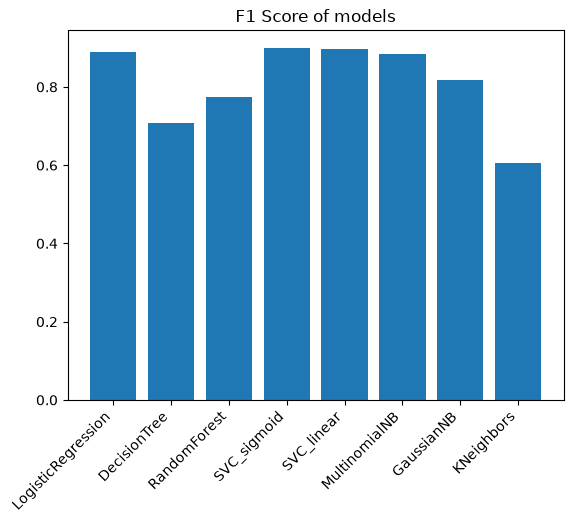

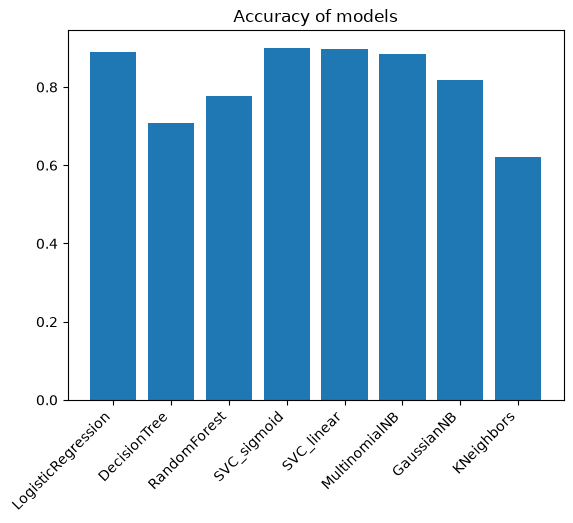

In [58]:
from joblib import Parallel, delayed

models = {
    "LogisticRegression": LogisticRegression(random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVC_sigmoid": SVC(kernel="sigmoid", random_state=42),
    "SVC_linear": SVC(kernel="linear", random_state=42),
    "MultinomialNB": MultinomialNB(),
    "GaussianNB": GaussianNB(),
    "KNeighbors": KNeighborsClassifier(),
}


def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    if isinstance(model, GaussianNB):
        X_train = X_train.toarray()
        X_test = X_test.toarray()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return name, (accuracy_score(y_test, y_pred), f1_score(y_test, y_pred, average="weighted"))


results = Parallel(n_jobs=-1,mmap_mode="c")(
    delayed(evaluate_model)(name, model, X_train_transformed, X_test_transformed, y_train, y_test)
    for name, model in models.items()
)
model_predictions = dict(results)


plt.bar(
    list(model_predictions.keys()),
    [model_predictions[model_name][1] for model_name in model_predictions],
)
plt.title("F1 Score of models")
plt.xticks(rotation=45, ha="right")
plt.show()

plt.bar(
    list(model_predictions.keys()),
    [model_predictions[model_name][0] for model_name in model_predictions],
)
plt.title("Accuracy of models")
plt.xticks(rotation=45, ha="right")
plt.show()

    


Vea que los mejores modelos en ``accuaracy``y ``F1 Score`` son: ``LogisticRegression``, ``SVC_sigmoid`` y ``SVC_linear``. A continuación, encontraremos los mejores parámetros de cada uno de estos modelos. 

In [ ]:
from itertools import product

VECTORIZER_OPTIONS = ["count", "tfidf"]
NGRAM_OPTIONS = [(1, 1), (1, 2), (1, 3)]

# Cada opción reemplaza el paso "vectorizers" completo, así los tres vectorizadores
# (texto, última oración y contraste) usan siempre el mismo tipo y ngram_range.
vectorizer_options = [
    build_preprocessor(vectorizer, ngram_range).named_steps["vectorizers"]
    for vectorizer, ngram_range in product(VECTORIZER_OPTIONS, NGRAM_OPTIONS)
]


def describe_vectorizer(column_transformer):
    """Devuelve el tipo de vectorizador y su ngram_range a partir del ColumnTransformer."""
    vectorizer = column_transformer.transformers[0][1]
    return type(vectorizer).__name__, str(vectorizer.ngram_range)


param_grids = {
    "LogisticRegression": (LogisticRegression(random_state=42, max_iter=1000), {
        "C": [0.1, 1, 1.1, 1.2],
        "solver": ["lbfgs", "newton-cg"],
    }),
    "SVC": (SVC(random_state=42), {
        "kernel": ["linear", "sigmoid"],
        "C": [0.1, 1, 1.1, 1.2],
    }),
}

best_models = {}
for name, (model, grid) in param_grids.items():
    # El preprocesamiento va dentro del pipeline para que el vectorizador se ajuste en cada fold
    pipeline = Pipeline(build_preprocessor().steps + [("clf", model)])
    full_grid = {
        "vectorizers": vectorizer_options,
        **{f"clf__{param}": values for param, values in grid.items()},
    }
    search = GridSearchCV(pipeline, full_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_

    vectorizer_name, ngram_range = describe_vectorizer(search.best_params_["vectorizers"])
    model_params = {k: v for k, v in search.best_params_.items() if k != "vectorizers"}
    print(f"{name}: {vectorizer_name} ngram={ngram_range} {model_params}  CV Accuracy={search.best_score_:.4f}")

    # Mejor CV accuracy para cada combinación de vectorizador y n-gramas
    cv_results = pd.DataFrame(search.cv_results_)
    cv_results[["vectorizer", "ngram_range"]] = cv_results["param_vectorizers"].apply(
        lambda ct: pd.Series(describe_vectorizer(ct))
    )
    effect = cv_results.pivot_table(
        index="vectorizer", columns="ngram_range", values="mean_test_score", aggfunc="max"
    )
    display(effect.round(4))
    effect.plot.bar(rot=0, ylabel="CV Accuracy", title=f"{name}: vectorizer and n-gram range")
    plt.ylim(effect.min().min() - 0.02, effect.max().max() + 0.01)
    plt.show()

    y_pred = search.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()


Fitting 5 folds for each of 48 candidates, totalling 240 fits
